# Cluster Quality Analytics

Comprehensive analysis of the current ChromaDB vector store and HDBSCAN clustering.
**Re-run this notebook** after switching embedding models to compare quality metrics side-by-side.

---

### Metrics reference

| Metric | Direction | Range | Description |
|---|---|---|---|
| **Silhouette score** (cosine) | ↑ higher better | −1 to +1 | Measures how similar each article is to its own cluster vs. the nearest other cluster. +1 = perfectly separated, 0 = on the boundary, −1 = likely misclustered. |
| **Davies-Bouldin index** | ↓ lower better | ≥ 0 | Average ratio of within-cluster spread to between-cluster distance. 0 = perfectly separated clusters; higher = more overlap. No fixed upper bound. |
| **Calinski-Harabasz score** | ↑ higher better | > 0 | Ratio of between-cluster dispersion to within-cluster dispersion. Higher means clusters are dense and well separated. No fixed upper bound; useful for relative comparisons. |
| **Noise ratio** | ↓ lower better | 0 to 1 | Fraction of articles HDBSCAN labelled as noise (cluster_id = −1). A very high noise ratio (>40%) may indicate the HDBSCAN `min_cluster_size` is too large, or that the embedding model is not capturing topic boundaries well. |
| **Mean intra-cluster cosine similarity** | ↑ higher better | −1 to +1 | Average pairwise cosine similarity between articles within the same cluster. A high value means the embedding model consistently places topically related content close together in vector space. |

---

### How to compare embedding models

1. Run all cells → copy the **Comparison baseline table** (Section 10) output.
2. Change `EMBEDDING_MODEL` in `backend/nlp/config.py`.
3. Wipe ChromaDB and re-ingest: `python -m backend.nlp.pipeline` (from scratch).
4. Re-run this notebook → compare the two baseline tables.
5. A better model should show: higher silhouette + Calinski-Harabász, lower Davies-Bouldin, lower noise ratio, higher intra-cluster similarity.

In [1]:
import sys, os
sys.path.insert(0, '/home/nektariostp/social-reaction-analysis-gr')
os.chdir('/home/nektariostp/social-reaction-analysis-gr')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from pathlib import Path

import umap
from sklearn.metrics import (
    silhouette_score,
    silhouette_samples,
    davies_bouldin_score,
    calinski_harabasz_score,
)

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid')

FIGURES_DIR = Path('notebooks/figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print('Setup complete. Figures will be saved to:', FIGURES_DIR.resolve())

Setup complete. Figures will be saved to: /home/nektariostp/social-reaction-analysis-gr/notebooks/figures


## 1 · Load data from ChromaDB

In [2]:
from backend.nlp.vectorstore import get_all

data = get_all(include=['embeddings', 'metadatas'])
ids       = data['ids']
embeddings = np.array(data['embeddings'], dtype=np.float32)
metadatas  = data['metadatas']

print(f'Total records  : {len(ids)}')
print(f'Embedding shape: {embeddings.shape}')

Total records  : 854
Embedding shape: (854, 768)


## 2 · Parse metadata into a DataFrame

In [3]:
records = []
for rec_id, meta in zip(ids, metadatas):
    records.append({
        'id'           : rec_id,
        'cluster_id'   : int(meta.get('cluster_id', -1)),
        'event_id'     : meta.get('event_id', ''),
        'source'       : meta.get('source', ''),
        'title'        : meta.get('title', ''),
        'published_at' : meta.get('published_at', ''),
        'is_noise'     : int(meta.get('cluster_id', -1)) == -1,
        'is_duplicate' : bool(meta.get('is_duplicate', False)),
    })

df = pd.DataFrame(records)

print('=== Summary ===')
print(f"Total records       : {len(df)}")
print(f"Clustered articles  : {(~df['is_noise']).sum()}")
print(f"Noise records       : {df['is_noise'].sum()}  ({100*df['is_noise'].mean():.1f}%)")
print(f"Duplicate records   : {df['is_duplicate'].sum()}")
print(f"Unique clusters     : {df[~df['is_noise']]['cluster_id'].nunique()}")
print(f"Unique event_ids    : {df['event_id'].nunique()}")
print(f"\nSources:")
print(df['source'].value_counts().to_string())

=== Summary ===
Total records       : 854
Clustered articles  : 242
Noise records       : 612  (71.7%)
Duplicate records   : 156
Unique clusters     : 48
Unique event_ids    : 45

Sources:
source
googlenews    799
gdelt_doc      55


## 3 · Cluster size distribution

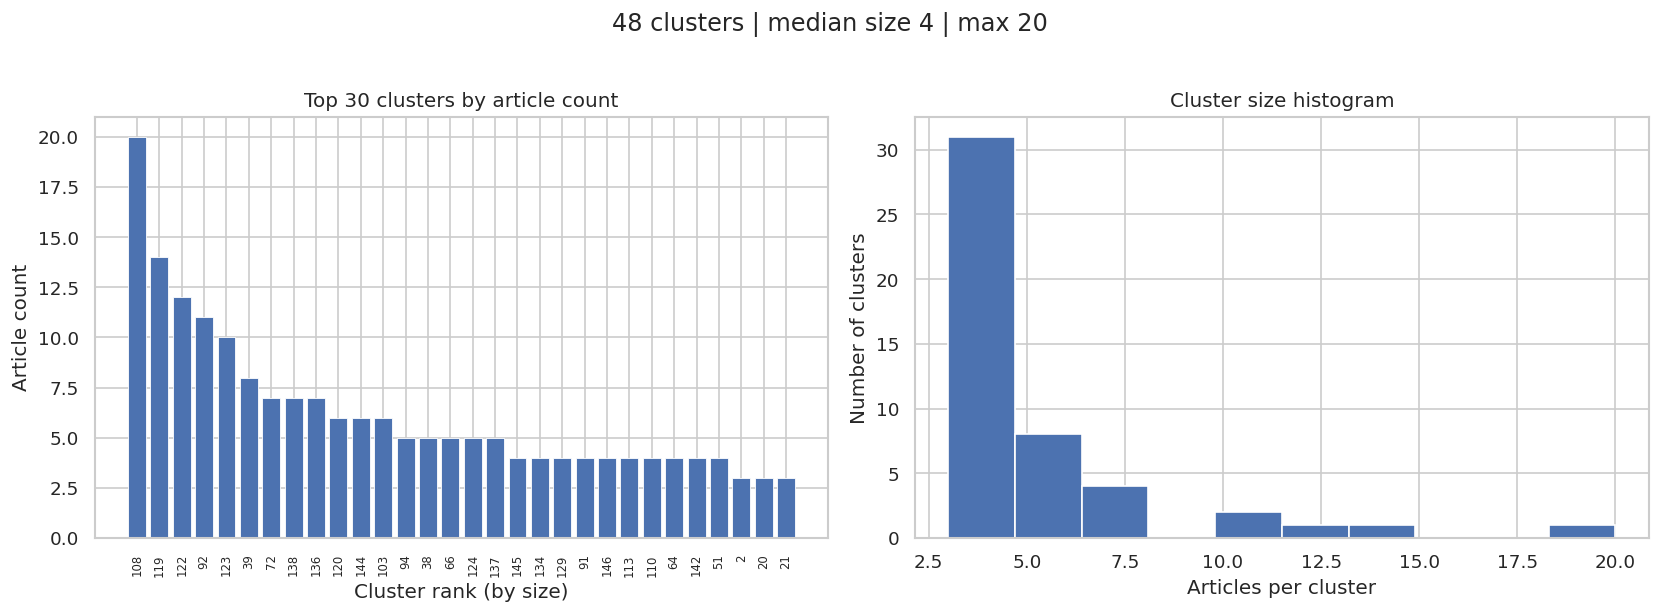

In [4]:
cluster_sizes = (
    df[~df['is_noise']]
    .groupby('cluster_id')
    .size()
    .sort_values(ascending=False)
)

top_n = min(30, len(cluster_sizes))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top-N clusters by size
axes[0].bar(
    range(top_n),
    cluster_sizes.head(top_n).values,
    color='#4C72B0', edgecolor='white', linewidth=0.5,
)
axes[0].set_xlabel('Cluster rank (by size)')
axes[0].set_ylabel('Article count')
axes[0].set_title(f'Top {top_n} clusters by article count')
axes[0].set_xticks(range(top_n))
axes[0].set_xticklabels(cluster_sizes.head(top_n).index, rotation=90, fontsize=7)

# Size histogram
axes[1].hist(cluster_sizes.values, bins=max(10, len(cluster_sizes)//5),
             color='#4C72B0', edgecolor='white')
axes[1].set_xlabel('Articles per cluster')
axes[1].set_ylabel('Number of clusters')
axes[1].set_title('Cluster size histogram')

plt.suptitle(
    f"{len(cluster_sizes)} clusters | "
    f"median size {cluster_sizes.median():.0f} | "
    f"max {cluster_sizes.max()}",
    y=1.02,
)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'cluster_size_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 4 · Record composition

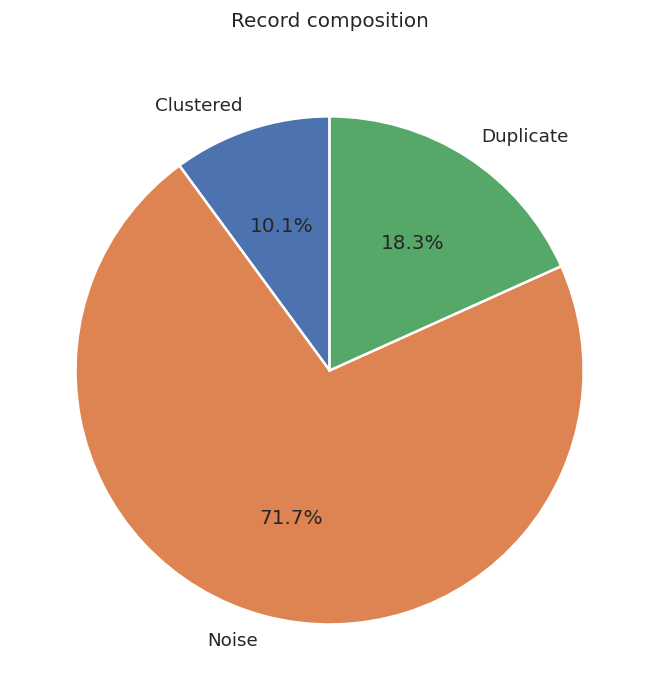

Clustered  :   86 (10.1%)
Noise      :  612 (71.7%)
Duplicate  :  156 (18.3%)


In [5]:
fig, ax = plt.subplots(figsize=(6, 6))

n_clustered  = (~df['is_noise'] & ~df['is_duplicate']).sum()
n_noise      = df['is_noise'].sum()
n_duplicates = df['is_duplicate'].sum()

wedge_labels = ['Clustered', 'Noise', 'Duplicate']
wedge_sizes  = [n_clustered, n_noise, n_duplicates]
wedge_colors = ['#4C72B0', '#DD8452', '#55A868']

wedges, texts, autotexts = ax.pie(
    wedge_sizes,
    labels=wedge_labels,
    autopct='%1.1f%%',
    colors=wedge_colors,
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=1.5),
)
ax.set_title('Record composition', pad=16)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'record_composition.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Clustered  : {n_clustered:4d} ({100*n_clustered/len(df):.1f}%)')
print(f'Noise      : {n_noise:4d} ({100*n_noise/len(df):.1f}%)')
print(f'Duplicate  : {n_duplicates:4d} ({100*n_duplicates/len(df):.1f}%)')

## 5 · UMAP 2D projection

Reduces 384-dimensional embeddings to 2D using cosine distance.
Clusters should appear as distinct visual groups if the embedding model captures semantic content well.

Running UMAP (typically 20-60 s)…
UMAP done.


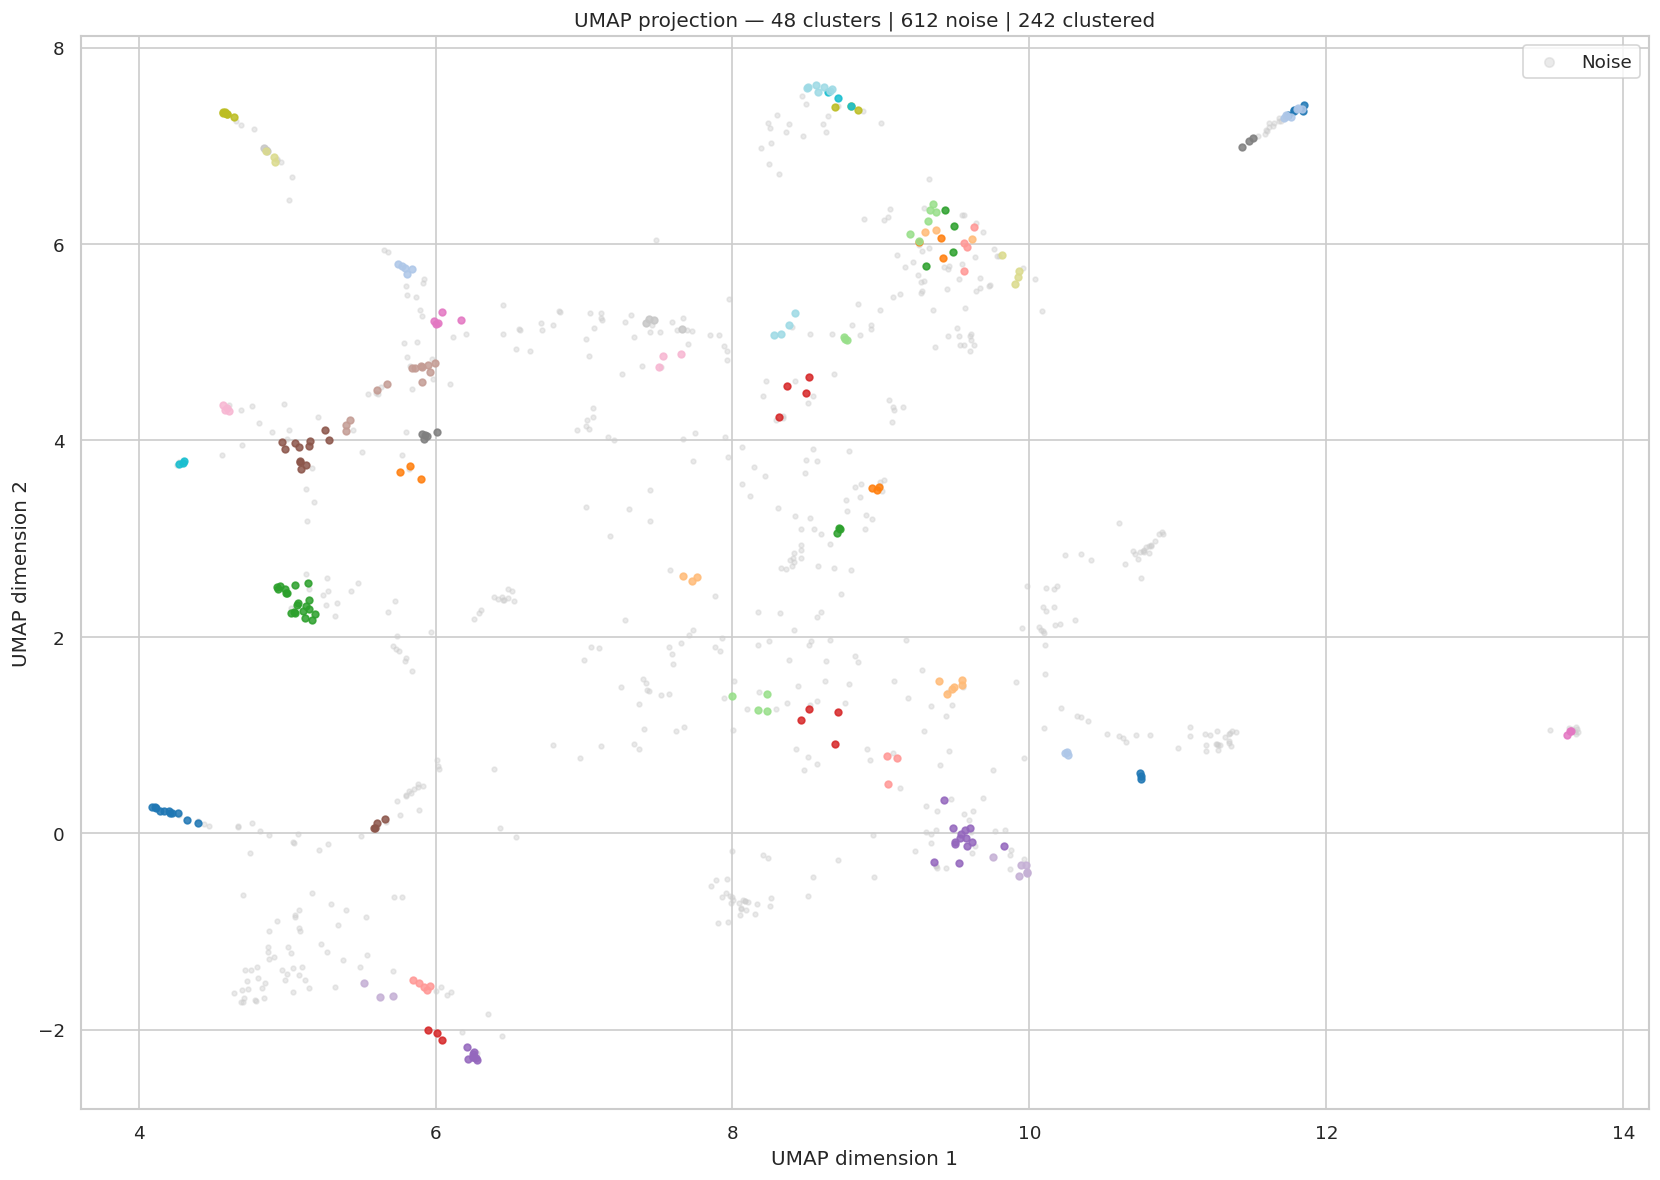

Saved → notebooks/figures/umap_projection.png


In [6]:
print('Running UMAP (typically 20-60 s)…')
reducer = umap.UMAP(
    n_components=2,
    metric='cosine',
    random_state=42,
    n_neighbors=15,
    min_dist=0.1,
)
emb2d = reducer.fit_transform(embeddings)
print('UMAP done.')

labels_arr    = df['cluster_id'].values
unique_labels = sorted([c for c in np.unique(labels_arr) if c != -1])
n_clusters    = len(unique_labels)

fig, ax = plt.subplots(figsize=(14, 10))

# Noise first (background)
noise_mask = labels_arr == -1
ax.scatter(
    emb2d[noise_mask, 0], emb2d[noise_mask, 1],
    c='#cccccc', s=8, alpha=0.4, label='Noise', zorder=1,
)

# Clustered articles — cycle through tab20
palette = cm.get_cmap('tab20', 20)
for i, cid in enumerate(unique_labels):
    mask = labels_arr == cid
    ax.scatter(
        emb2d[mask, 0], emb2d[mask, 1],
        c=[palette(i % 20)], s=16, alpha=0.85, zorder=2,
    )

ax.set_title(
    f'UMAP projection — {n_clusters} clusters | '
    f'{noise_mask.sum()} noise | '
    f'{(~noise_mask).sum()} clustered',
    fontsize=12,
)
ax.set_xlabel('UMAP dimension 1')
ax.set_ylabel('UMAP dimension 2')
ax.legend(loc='upper right', markerscale=2, framealpha=0.8)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'umap_projection.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {FIGURES_DIR / "umap_projection.png"}')

## 6 · Silhouette analysis

**What it measures**: For each article $i$, the silhouette coefficient is defined as:

$$s(i) = \frac{b(i) - a(i)}{\max(a(i),\; b(i))}$$

where:
- $a(i)$ = mean distance from article $i$ to all other articles **in the same cluster** (intra-cluster dissimilarity)
- $b(i)$ = mean distance from article $i$ to all articles **in the nearest other cluster** (inter-cluster dissimilarity)

**Interpretation of the per-cluster bar chart**:
- **Blue bars (≥ 0)**: cluster is more similar internally than to its neighbours — good.
- **Red bars (< 0)**: articles in this cluster are, on average, closer to a neighbouring cluster than to their own — the cluster may be fragmented, over-split, or contain mixed topics.
- **Dashed line**: the overall mean silhouette across all non-noise articles — the headline quality number.

**Context for this project**: News articles about the same event but from different sources should cluster tightly (high $s$). Articles that discuss tangentially related topics (e.g. the word "απεργία" appearing in an unrelated context) will drag individual cluster scores down.

**Typical ranges for NLP/news clustering**:
- > 0.35 → reasonable separation
- > 0.55 → good separation
- > 0.70 → very good (rarely achieved on raw news embeddings)

Computing silhouette scores for 242 non-noise records…
Overall silhouette score (cosine): 0.4911


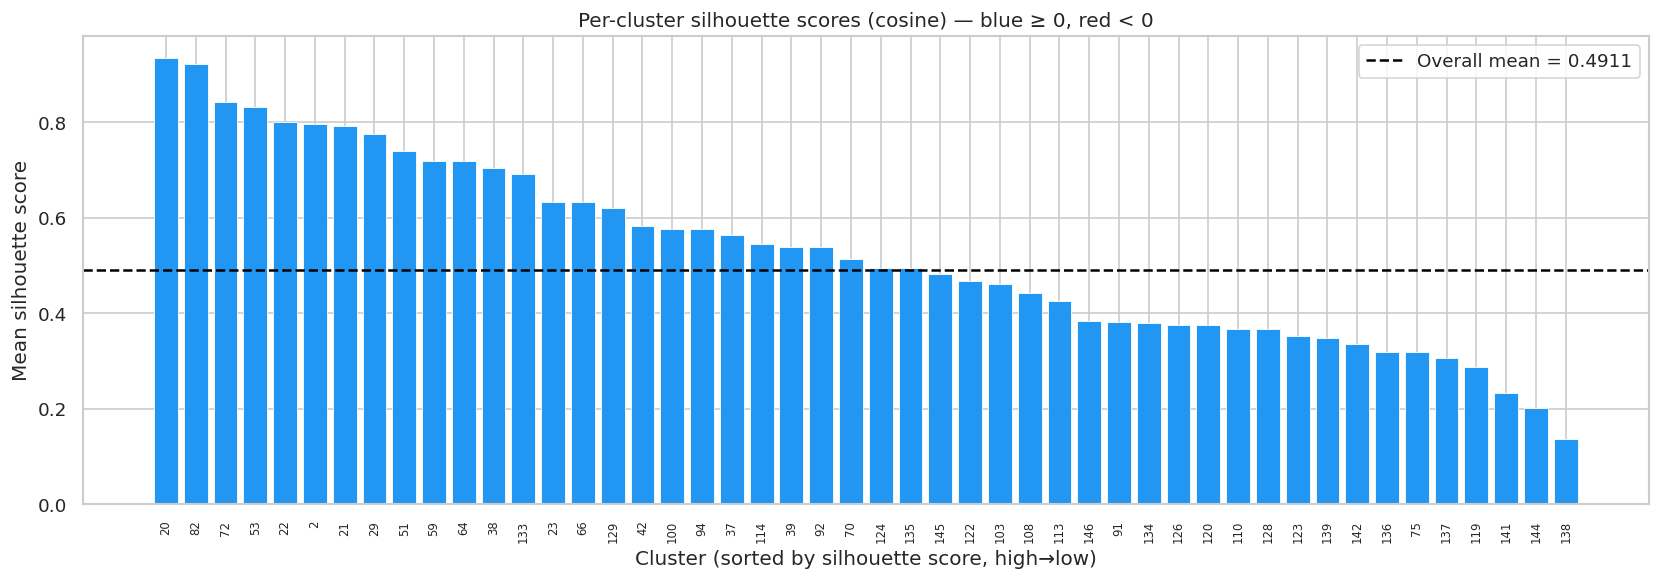

Clusters with negative silhouette: 0 / 48


In [7]:
non_noise_mask   = labels_arr != -1
X_nn             = embeddings[non_noise_mask]
labels_nn        = labels_arr[non_noise_mask]

print(f'Computing silhouette scores for {non_noise_mask.sum()} non-noise records…')
sil_global  = silhouette_score(X_nn, labels_nn, metric='cosine')
sil_samples = silhouette_samples(X_nn, labels_nn, metric='cosine')
print(f'Overall silhouette score (cosine): {sil_global:.4f}')

# Per-cluster mean silhouette
cluster_sil = {}
for cid in unique_labels:
    mask = labels_nn == cid
    cluster_sil[cid] = float(sil_samples[mask].mean())

sil_df = (
    pd.DataFrame({'cluster_id': list(cluster_sil.keys()),
                  'silhouette': list(cluster_sil.values())})
    .sort_values('silhouette', ascending=False)
)

fig, ax = plt.subplots(figsize=(14, 5))
bar_colors = ['#2196F3' if v >= 0 else '#F44336' for v in sil_df['silhouette']]
ax.bar(
    range(len(sil_df)),
    sil_df['silhouette'].values,
    color=bar_colors, edgecolor='white', linewidth=0.5,
)
ax.axhline(
    sil_global, color='black', linestyle='--', linewidth=1.5,
    label=f'Overall mean = {sil_global:.4f}',
)
ax.axhline(0, color='black', linewidth=0.7, alpha=0.4)
ax.set_xlabel('Cluster (sorted by silhouette score, high→low)')
ax.set_ylabel('Mean silhouette score')
ax.set_title('Per-cluster silhouette scores (cosine) — blue ≥ 0, red < 0')
ax.set_xticks(range(len(sil_df)))
ax.set_xticklabels(sil_df['cluster_id'].values, rotation=90, fontsize=7)
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'silhouette_per_cluster.png', dpi=150, bbox_inches='tight')
plt.show()

n_neg = (sil_df['silhouette'] < 0).sum()
print(f'Clusters with negative silhouette: {n_neg} / {len(sil_df)}')

## 7 · Additional quality indices

### Davies-Bouldin index (DB)

For each cluster $i$, DB computes the worst-case "similarity" to any other cluster $j$:

$$DB = \frac{1}{k} \sum_{i=1}^{k} \max_{j \neq i} \left( \frac{\sigma_i + \sigma_j}{d(c_i,\, c_j)} \right)$$

where $\sigma_i$ is the mean distance of cluster $i$'s members from their centroid (spread), and $d(c_i, c_j)$ is the distance between centroids $i$ and $j$.

- **Lower = better**. A value near 0 means clusters are compact and far apart.
- **Sensitive to outlier clusters**: one diffuse cluster inflates the whole score.
- Unlike silhouette, Davies-Bouldin uses centroid distances, so it's less informative when clusters have irregular shapes — common in NLP.

### Calinski-Harabász score (CH)

Also called the **Variance Ratio Criterion**:

$$CH = \frac{B_k / (k-1)}{W_k / (n-k)}$$

where $B_k$ is the between-cluster dispersion (how far apart cluster centroids are) and $W_k$ is the within-cluster dispersion (how spread out each cluster is), $k$ = number of clusters, $n$ = number of points.

- **Higher = better** — more between-cluster separation relative to within-cluster spread.
- Tends to favour a larger number of compact clusters; interpret alongside silhouette.
- Very sensitive to the number of clusters: directly compare CH scores only when $k$ is similar between runs.

### Using all three together

| Scenario | Silhouette | DB | CH |
|---|---|---|---|
| Both models produce similar silhouette but different CH | Look at CH to break the tie (higher = more compact clusters) |
| DB is low but silhouette is also low | Clusters are close together but internally loose — likely too many clusters |
| High silhouette but low CH | Cluster sizes are very unequal (one giant cluster, many tiny ones)  |

Silhouette score (cosine)   : 0.4911  ↑ higher better
Davies-Bouldin index        : 1.0836  ↓ lower better
Calinski-Harabasz score     : 16.15  ↑ higher better


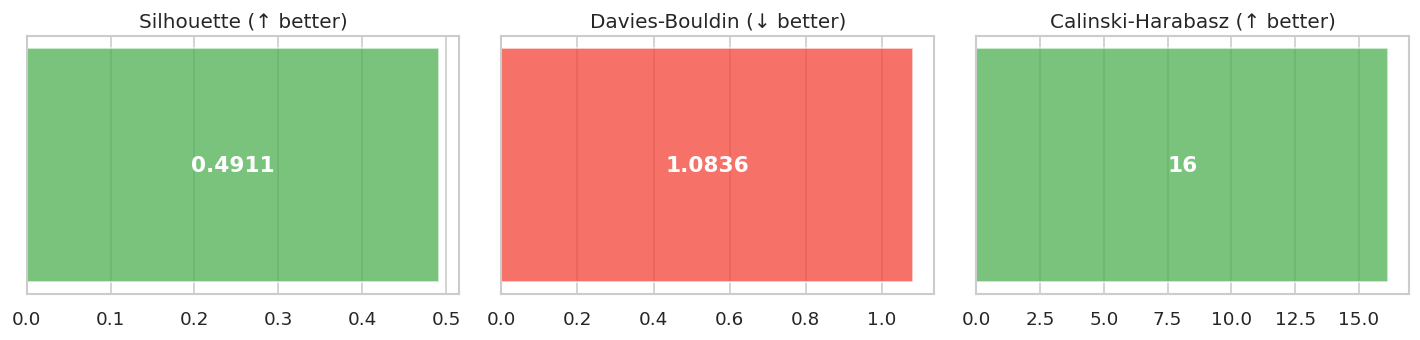

In [8]:
db_score = davies_bouldin_score(X_nn, labels_nn)
ch_score = calinski_harabasz_score(X_nn, labels_nn)

print(f'Silhouette score (cosine)   : {sil_global:.4f}  ↑ higher better')
print(f'Davies-Bouldin index        : {db_score:.4f}  ↓ lower better')
print(f'Calinski-Harabasz score     : {ch_score:.2f}  ↑ higher better')

# Visual summary bar
fig, axes = plt.subplots(1, 3, figsize=(12, 3))

def _gauge(ax, value, label, fmt, good_direction='high'):
    color = '#4CAF50' if good_direction == 'high' else '#F44336'
    ax.barh([0], [abs(value)], color=color, alpha=0.75)
    ax.set_yticks([])
    ax.set_title(label)
    ax.text(abs(value)/2, 0, fmt.format(value), ha='center', va='center',
            fontsize=13, fontweight='bold', color='white')

_gauge(axes[0], sil_global, 'Silhouette (↑ better)', '{:.4f}', 'high')
_gauge(axes[1], db_score,   'Davies-Bouldin (↓ better)', '{:.4f}', 'low')
_gauge(axes[2], ch_score,   'Calinski-Harabasz (↑ better)', '{:.0f}', 'high')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'quality_indices.png', dpi=150, bbox_inches='tight')
plt.show()

## 8 · Intra-cluster cohesion

**What it measures**: For each cluster, every pair of member articles is compared using cosine similarity. The mean of all pairwise scores is the cluster's **cohesion**.

Because embeddings are L2-normalised, cosine similarity equals the dot product — values near +1 mean two articles occupy nearly the same position in embedding space (very similar meaning), values near 0 mean they are orthogonal (unrelated).

**How to read the charts**:
- **Box plot**: the central box spans the interquartile range (IQR) of cluster cohesion scores across all clusters; the white line is the median. Outlier dots are clusters with unusually high or low internal similarity.
- **Histogram**: the distribution of cluster cohesion. A peak near 0.8–0.9 suggests tight, well-formed clusters; a spread toward 0.3–0.5 suggests many loose or mixed-topic clusters.

**Relationship to silhouette**: A cluster can have high intra-similarity but a negative silhouette score if a *neighbouring* cluster is even more similar to it. In other words, cohesion measures internal tightness; silhouette accounts for separation from other clusters. Both together give the full picture.

**Practical threshold for this project**: At the current model (`paraphrase-multilingual-MiniLM-L12-v2`, 384 dimensions), a mean intra-cluster similarity of > 0.65 per cluster is a reasonable sign that the cluster represents a single real-world event rather than a loose keyword association.

Computing intra-cluster pairwise cosine similarity…
Intra-cluster cosine sim — mean: 0.8502, median: 0.8456, min: 0.7801


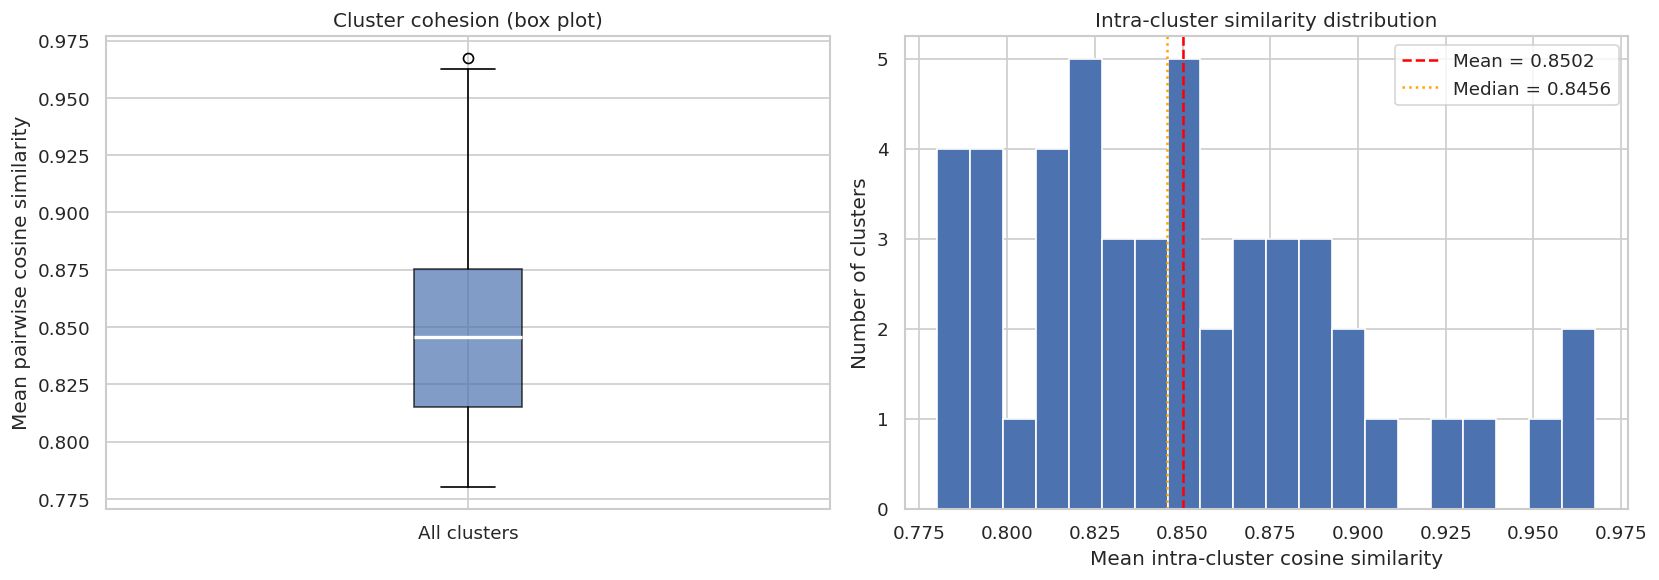

In [9]:
print('Computing intra-cluster pairwise cosine similarity…')
intra_sims = {}
for cid in unique_labels:
    mask = labels_nn == cid
    vecs = X_nn[mask]  # L2-normalised → cosine sim = dot product
    if len(vecs) < 2:
        intra_sims[cid] = 1.0
        continue
    sim_matrix = vecs @ vecs.T
    np.fill_diagonal(sim_matrix, np.nan)
    intra_sims[cid] = float(np.nanmean(sim_matrix))

sim_values = np.array(list(intra_sims.values()))
print(f'Intra-cluster cosine sim — mean: {sim_values.mean():.4f}, '
      f'median: {np.median(sim_values):.4f}, '
      f'min: {sim_values.min():.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
axes[0].boxplot(
    sim_values, vert=True, patch_artist=True,
    boxprops=dict(facecolor='#4C72B0', alpha=0.7),
    medianprops=dict(color='white', linewidth=2),
)
axes[0].set_ylabel('Mean pairwise cosine similarity')
axes[0].set_title('Cluster cohesion (box plot)')
axes[0].set_xticks([1])
axes[0].set_xticklabels(['All clusters'])

# Histogram
axes[1].hist(sim_values, bins=20, color='#4C72B0', edgecolor='white')
axes[1].axvline(sim_values.mean(), color='red', linestyle='--',
                label=f'Mean = {sim_values.mean():.4f}')
axes[1].axvline(np.median(sim_values), color='orange', linestyle=':',
                label=f'Median = {np.median(sim_values):.4f}')
axes[1].set_xlabel('Mean intra-cluster cosine similarity')
axes[1].set_ylabel('Number of clusters')
axes[1].set_title('Intra-cluster similarity distribution')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'intra_cluster_similarity.png', dpi=150, bbox_inches='tight')
plt.show()

## 9 · Worst-performing clusters

Clusters with the lowest silhouette scores are most likely misclassified or noisy.
Inspect these to understand where the embedding model or HDBSCAN parameters need improvement.

In [10]:
worst = sil_df.tail(10).copy()
worst['intra_sim'] = worst['cluster_id'].map(intra_sims).round(4)
worst['size'] = worst['cluster_id'].map(cluster_sizes.to_dict())
worst['silhouette'] = worst['silhouette'].round(4)

print('=== 10 worst clusters (lowest silhouette) ===')
print(worst[['cluster_id', 'silhouette', 'intra_sim', 'size']].to_string(index=False))

# Show representative titles for worst 3 clusters
print('\n=== Sample articles from worst 3 clusters ===')
for cid in worst['cluster_id'].tail(3).values:
    subset = df[df['cluster_id'] == cid][['title', 'source']].head(5)
    print(f'\n--- Cluster {cid} (sil={cluster_sil[cid]:.3f}) ---')
    for _, row in subset.iterrows():
        print(f"  [{row['source']}] {row['title'][:100]}")

=== 10 worst clusters (lowest silhouette) ===
 cluster_id  silhouette  intra_sim  size
        123      0.3523     0.7900    10
        139      0.3478     0.8197     3
        142      0.3348     0.8393     4
        136      0.3176     0.8753     7
         75      0.3176     0.8528     3
        137      0.3065     0.8758     5
        119      0.2873     0.8602    14
        141      0.2326     0.8165     3
        144      0.2006     0.7854     6
        138      0.1369     0.8439     7

=== Sample articles from worst 3 clusters ===

--- Cluster 141 (sil=0.233) ---
  [googlenews] Στάση εργασίας σε υπουργείο για κατάργηση επιτροπών ΕΦΚΑ
  [googlenews] Απεργούν οι συμβασιούχοι Εργασιακοί Σύμβουλοι του ΚΠΑ2 Βόλου
  [googlenews] Κινητοποίηση στο υπ. Εργασίας ενάντια στις νομοθετικές ρυθμίσεις που καταργούν τις Τοπικές Διοικητικ

--- Cluster 144 (sil=0.201) ---
  [googlenews] Κήρυξη στάση εργασίας -Συγκέντρωση 4.3 στο Εφετείο Αθηνών
  [googlenews] ΑΔΕΔΥ: Κήρυξε πανελλαδική στάση εργασί

## 10 · Comparison baseline table

Copy the output of this cell before and after switching embedding models to compare quality.
Higher silhouette / Calinski-Harabasz and lower Davies-Bouldin = better embeddings.

In [11]:
from backend.nlp.config import EMBEDDING_MODEL

summary = {
    'Model'                           : EMBEDDING_MODEL,
    'Embedding dimensions'            : embeddings.shape[1],
    'Total records'                   : len(ids),
    'Clustered records'               : int(non_noise_mask.sum()),
    'Noise records'                   : int((~non_noise_mask).sum()),
    'Noise ratio (%)'                 : f"{100*(~non_noise_mask).sum()/len(ids):.1f}",
    'Number of clusters'              : n_clusters,
    'Median cluster size'             : f"{cluster_sizes.median():.0f}",
    'Max cluster size'                : int(cluster_sizes.max()),
    'Silhouette score (cosine)'       : f"{sil_global:.4f}",
    'Davies-Bouldin index'            : f"{db_score:.4f}",
    'Calinski-Harabasz score'         : f"{ch_score:.2f}",
    'Mean intra-cluster similarity'   : f"{sim_values.mean():.4f}",
    'Median intra-cluster similarity' : f"{np.median(sim_values):.4f}",
    'Clusters with negative sil.'     : int((sil_df['silhouette'] < 0).sum()),
}

print('\n' + '='*62)
print('  EMBEDDING QUALITY BASELINE — COMPARISON TABLE')
print('='*62)
for k, v in summary.items():
    print(f'  {k:<40} {v}')
print('='*62)
print('Re-run this notebook after switching embedding model to compare.')


  EMBEDDING QUALITY BASELINE — COMPARISON TABLE
  Model                                    sentence-transformers/paraphrase-multilingual-mpnet-base-v2
  Embedding dimensions                     768
  Total records                            854
  Clustered records                        242
  Noise records                            612
  Noise ratio (%)                          71.7
  Number of clusters                       48
  Median cluster size                      4
  Max cluster size                         20
  Silhouette score (cosine)                0.4911
  Davies-Bouldin index                     1.0836
  Calinski-Harabasz score                  16.15
  Mean intra-cluster similarity            0.8502
  Median intra-cluster similarity          0.8456
  Clusters with negative sil.              0
Re-run this notebook after switching embedding model to compare.


## Figures saved

All charts are saved to `notebooks/figures/`:

| File | Contents |
|---|---|
| `cluster_size_distribution.png` | Top-N cluster sizes + histogram |
| `record_composition.png` | Clustered / noise / duplicate pie |
| `umap_projection.png` | 2D projection coloured by cluster |
| `silhouette_per_cluster.png` | Per-cluster silhouette bar chart |
| `quality_indices.png` | Silhouette / DB / CH gauge bars |
| `intra_cluster_similarity.png` | Cohesion box plot + histogram |